In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

## 1. Data Loading

In [27]:
from sklearn.datasets import fetch_openml# 导入从 OpenML 获取数据集的函数

dataset = fetch_openml(name="qsar-biodeg", as_frame=True, parser="auto")#获取数据

X = dataset.data#提取数据特征
y = dataset.target#提取数据标签

print("X shape:", X.shape)#检查特征表
print("y shape:", y.shape)#检查标签表

X shape: (1055, 41)
y shape: (1055,)


D:\Code\biodegradability-project\.venv\Lib\site-packages\sklearn\datasets\_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name qsar-biodeg exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=1494
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=46952

  warn(warning_msg)


In [28]:
print(X.head())

      V1      V2  V3  V4  V5  V6  V7    V8  V9  V10  ...  V32  V33  V34  V35  \
0  3.919  2.6909   0   0   0   0   0  31.4   2    0  ...    0    0    0    0   
1  4.170  2.1144   0   0   0   0   0  30.8   1    1  ...    0    0    0    0   
2  3.932  3.2512   0   0   0   0   0  26.7   2    4  ...    0    0    0    1   
3  3.000  2.7098   0   0   0   0   0  20.0   0    2  ...    0    0    0    1   
4  4.236  3.3944   0   0   0   0   0  29.4   2    4  ...    0    0    0    0   

     V36    V37  V38    V39  V40  V41  
0  2.949  1.591    0  7.253    0    0  
1  3.315  1.967    0  7.257    0    0  
2  3.076  2.417    0  7.601    0    0  
3  3.046  5.000    0  6.690    0    0  
4  3.351  2.405    0  8.003    0    0  

[5 rows x 41 columns]


In [29]:
print(y.head())#快速预览
print(y.unique())#查看不同类别
print(y.value_counts())#统计这一列里，每个取值各出现了多少次

0    2
1    2
2    2
3    2
4    2
Name: Class, dtype: category
Categories (2, str): ['1', '2']
['2', '1']
Categories (2, str): ['1', '2']
Class
1    699
2    356
Name: count, dtype: int64


In [30]:
print(X.columns.tolist())#标签到底有哪些类别

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41']


## 2. Label Mapping and Feature Renaming

In [31]:
descriptor_names = [
    "SpMax_L", "J_Dz(e)", "nHM", "F01[N-N]", "F04[C-N]", "NssssC", "nCb-", "C%",
    "nCp", "nO", "F03[C-N]", "SdssC", "HyWi_B(m)", "LOC", "SM6_L", "F03[C-O]",
    "Me", "Mi", "nN-N", "nArNO2", "nCRX3", "SpPosA_B(p)", "nCIR", "B01[C-Br]",
    "B03[C-Cl]", "N-073", "SpMax_A", "Psi_i_1d", "B04[C-Br]", "SdO", "TI2_L",
    "nCrt", "C-026", "F02[C-N]", "nHDon", "SpMax_B(m)", "Psi_i_A", "nN",
    "SM6_B(m)", "nArCOOR", "nX"
]

X.columns = descriptor_names

print(X.head())

   SpMax_L  J_Dz(e)  nHM  F01[N-N]  F04[C-N]  NssssC  nCb-    C%  nCp  nO  \
0    3.919   2.6909    0         0         0       0     0  31.4    2   0   
1    4.170   2.1144    0         0         0       0     0  30.8    1   1   
2    3.932   3.2512    0         0         0       0     0  26.7    2   4   
3    3.000   2.7098    0         0         0       0     0  20.0    0   2   
4    4.236   3.3944    0         0         0       0     0  29.4    2   4   

   ...  nCrt  C-026  F02[C-N]  nHDon  SpMax_B(m)  Psi_i_A  nN  SM6_B(m)  \
0  ...     0      0         0      0       2.949    1.591   0     7.253   
1  ...     0      0         0      0       3.315    1.967   0     7.257   
2  ...     0      0         0      1       3.076    2.417   0     7.601   
3  ...     0      0         0      1       3.046    5.000   0     6.690   
4  ...     0      0         0      0       3.351    2.405   0     8.003   

   nArCOOR  nX  
0        0   0  
1        0   0  
2        0   0  
3        0   0  
4

In [32]:
y_named = y.astype(str).map({"1": "NRB", "2": "RB"})

print(y_named.head())
print(y_named.value_counts())

0    RB
1    RB
2    RB
3    RB
4    RB
Name: Class, dtype: str
Class
NRB    699
RB     356
Name: count, dtype: int64


## 3. Data Preparation

In [33]:
df = X.copy()
df["Class"] = y_named

print(df.shape)
print(df.head())

(1055, 42)
   SpMax_L  J_Dz(e)  nHM  F01[N-N]  F04[C-N]  NssssC  nCb-    C%  nCp  nO  \
0    3.919   2.6909    0         0         0       0     0  31.4    2   0   
1    4.170   2.1144    0         0         0       0     0  30.8    1   1   
2    3.932   3.2512    0         0         0       0     0  26.7    2   4   
3    3.000   2.7098    0         0         0       0     0  20.0    0   2   
4    4.236   3.3944    0         0         0       0     0  29.4    2   4   

   ...  C-026  F02[C-N]  nHDon  SpMax_B(m)  Psi_i_A  nN  SM6_B(m)  nArCOOR  \
0  ...      0         0      0       2.949    1.591   0     7.253        0   
1  ...      0         0      0       3.315    1.967   0     7.257        0   
2  ...      0         0      1       3.076    2.417   0     7.601        0   
3  ...      0         0      1       3.046    5.000   0     6.690        0   
4  ...      0         0      0       3.351    2.405   0     8.003        0   

   nX  Class  
0   0     RB  
1   0     RB  
2   0     RB

## 4. Basic Data Inspection

In [34]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 42 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SpMax_L      1055 non-null   float64
 1   J_Dz(e)      1055 non-null   float64
 2   nHM          1055 non-null   int64  
 3   F01[N-N]     1055 non-null   int64  
 4   F04[C-N]     1055 non-null   int64  
 5   NssssC       1055 non-null   int64  
 6   nCb-         1055 non-null   int64  
 7   C%           1055 non-null   float64
 8   nCp          1055 non-null   int64  
 9   nO           1055 non-null   int64  
 10  F03[C-N]     1055 non-null   int64  
 11  SdssC        1055 non-null   float64
 12  HyWi_B(m)    1055 non-null   float64
 13  LOC          1055 non-null   float64
 14  SM6_L        1055 non-null   float64
 15  F03[C-O]     1055 non-null   int64  
 16  Me           1055 non-null   float64
 17  Mi           1055 non-null   float64
 18  nN-N         1055 non-null   int64  
 19  nArNO2       1055

In [35]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

SpMax_L     0
J_Dz(e)     0
nHM         0
F01[N-N]    0
F04[C-N]    0
NssssC      0
nCb-        0
C%          0
nCp         0
nO          0
dtype: int64


## 5. Class Distribution

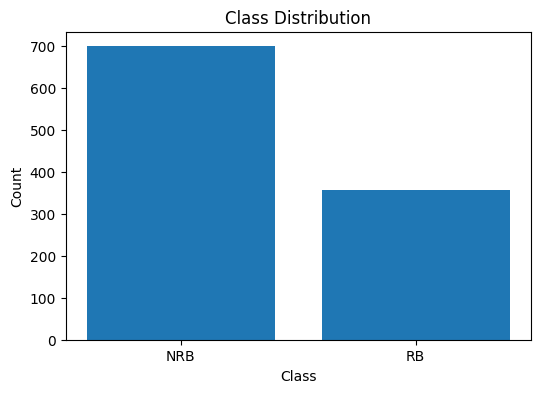

In [36]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [37]:
features_to_check = ["C%", "nO", "nN", "nHDon", "nX"]

print(df[features_to_check].describe())

                C%           nO           nN        nHDon           nX
count  1055.000000  1055.000000  1055.000000  1055.000000  1055.000000
mean     37.055640     1.803791     0.686256     0.961137     0.723223
std       9.144466     1.775435     1.090389     1.257013     2.239286
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%      30.450000     0.000000     0.000000     0.000000     0.000000
50%      37.500000     2.000000     0.000000     1.000000     0.000000
75%      43.400000     3.000000     1.000000     2.000000     0.000000
max      60.700000    12.000000     8.000000     7.000000    27.000000


In [38]:
print(df.groupby("Class")[features_to_check].mean())

              C%        nO        nN     nHDon        nX
Class                                                   
NRB    38.370672  1.579399  0.889843  0.985694  1.065808
RB     34.473596  2.244382  0.286517  0.912921  0.050562


<Figure size 600x400 with 0 Axes>

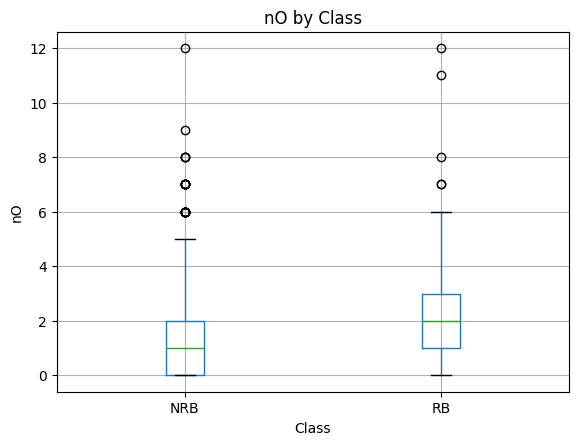

In [39]:
plt.figure(figsize=(6, 4))
df.boxplot(column="nO", by="Class")
plt.title("nO by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("nO")
plt.show()

<Figure size 600x400 with 0 Axes>

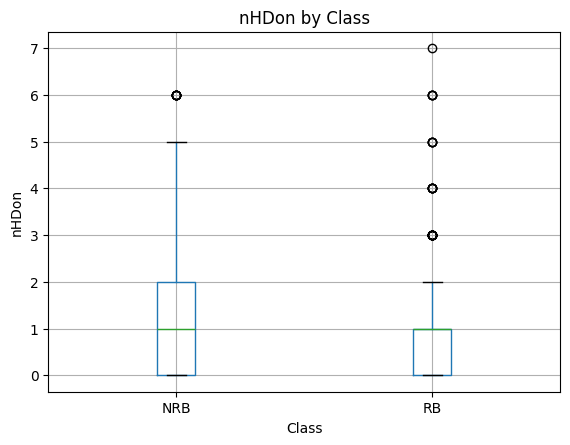

In [40]:
plt.figure(figsize=(6, 4))
df.boxplot(column="nHDon", by="Class")
plt.title("nHDon by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("nHDon")
plt.show()

<Figure size 600x400 with 0 Axes>

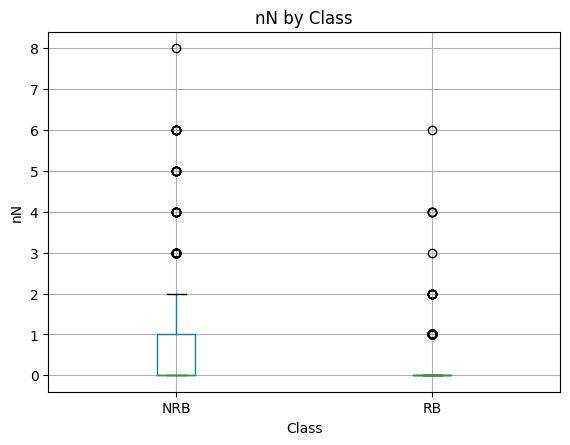

In [41]:
plt.figure(figsize=(6, 4))
df.boxplot(column="nN", by="Class")
plt.title("nN by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("nN")
plt.show()

<Figure size 600x400 with 0 Axes>

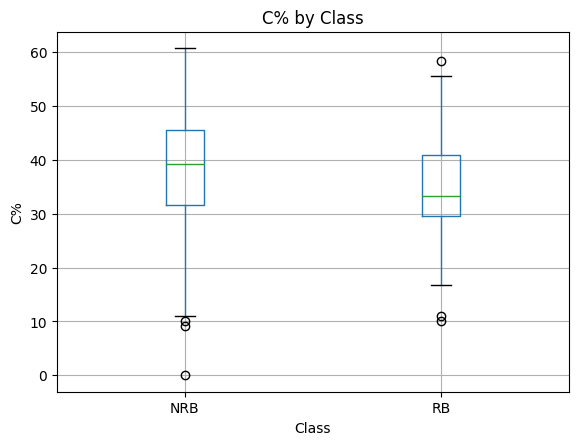

In [42]:
plt.figure(figsize=(6, 4))
df.boxplot(column="C%", by="Class")
plt.title("C% by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("C%")
plt.show()

<Figure size 600x400 with 0 Axes>

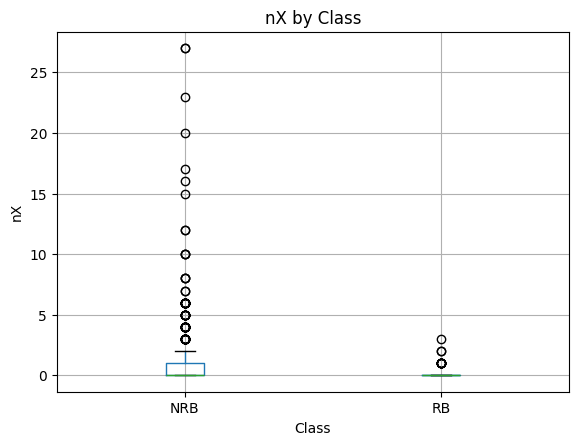

In [43]:
plt.figure(figsize=(6, 4))
df.boxplot(column="nX", by="Class")
plt.title("nX by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("nX")
plt.show()

In [44]:
features_to_check = ["C%", "nO", "nN", "nHDon", "nX"]

comparison_table = df.groupby("Class")[features_to_check].agg(["mean", "median"]).round(3)

comparison_table

C%            nO            nN         nHDon            nX       
         mean median   mean median   mean median   mean median   mean median
Class                                                                       
NRB    38.371   39.2  1.579    1.0  0.890    0.0  0.986    1.0  1.066    0.0
RB     34.474   33.3  2.244    2.0  0.287    0.0  0.913    1.0  0.051    0.0

## Preliminary comparison of interpretable descriptors

The comparison table confirms the patterns observed in the boxplots. The RB class shows higher mean and median values of nO, suggesting that readily biodegradable compounds tend to contain more oxygen-related structural features. In contrast, NRB has higher mean and median values of C%, indicating that carbon proportion may be associated with lower biodegradability.

For nX, both classes have a median of 0, but NRB has a much higher mean, which suggests that non-zero and larger nX values occur more frequently in NRB compounds. A similar but weaker pattern is observed for nN. By contrast, nHDon shows very similar statistics across the two classes, so its individual discriminative power appears limited.

Overall, nO, C%, and nX appear to be the most informative interpretable descriptors among this small subset.

In [45]:
corr_features = ["C%", "nO", "nN", "nHDon", "nX"]

corr_matrix = df[corr_features].corr()

corr_matrix

,C%,nO,nN,nHDon,nX
C%,1.000000,-0.146550,-0.091935,-0.237641,0.046641
nO,-0.146550,1.000000,0.026002,0.200639,-0.121538
nN,-0.091935,0.026002,1.000000,0.408499,-0.084558
nHDon,-0.237641,0.200639,0.408499,1.000000,-0.103258
nX,0.046641,-0.121538,-0.084558,-0.103258,1.000000


The selected interpretable descriptors do not show strong pairwise correlations overall. The strongest positive relationship is observed between nN and nHDon, while most other feature pairs are only weakly correlated. This suggests that these descriptors may provide complementary rather than highly redundant information for classification.

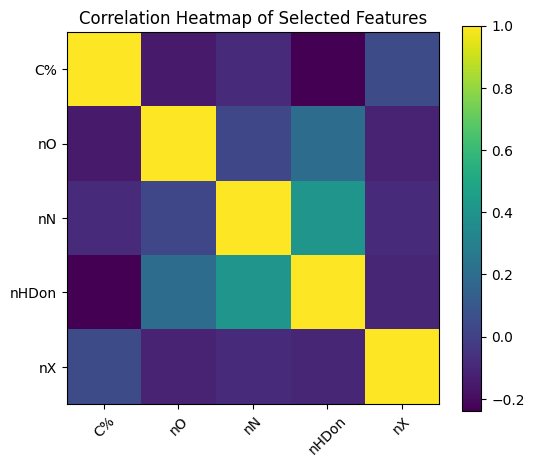

In [46]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_features)), corr_features, rotation=45)
plt.yticks(range(len(corr_features)), corr_features)

plt.title("Correlation Heatmap of Selected Features")
plt.show()

In [47]:
numeric_df = df.drop(columns="Class")#删除非数据列

class_mean = df.groupby("Class").mean(numeric_only=True)#按 Class 分组，分别计算 NRB 和 RB 在每个特征上的平均值

mean_diff = (class_mean.loc["RB"] - class_mean.loc["NRB"]).abs()#取出 NRB，RB 那一行的所有特征均值 相减得到每个特征在两类之间的均值差

overall_std = numeric_df.std()#标准差

feature_screen = pd.DataFrame({
    "NRB_mean": class_mean.loc["NRB"],
    "RB_mean": class_mean.loc["RB"],
    "abs_mean_diff": mean_diff,
    "overall_std": overall_std
})

feature_screen["separation_score"] = feature_screen["abs_mean_diff"] / feature_screen["overall_std"]#构造区分度分数

feature_screen = feature_screen.sort_values("separation_score", ascending=False).round(3)#区分度排序

feature_screen.head(10)

,NRB_mean,RB_mean,abs_mean_diff,overall_std,separation_score
SpMax_L,4.937,4.479,0.458,0.547,0.837
SpMax_A,2.279,2.092,0.186,0.226,0.824
SpPosA_B(p),1.264,1.188,0.076,0.096,0.787
SM6_B(m),8.954,7.991,0.963,1.242,0.775
HyWi_B(m),3.620,3.196,0.425,0.584,0.727
SM6_L,10.165,9.491,0.674,0.929,0.726
nCb-,2.182,0.596,1.586,2.225,0.713
C-026,1.229,0.205,1.024,1.520,0.673
nHM,1.029,0.104,0.925,1.462,0.632
SpMax_B(m),4.125,3.513,0.612,1.000,0.612


## Preliminary screening of candidate important features
The preliminary screening across all 41 descriptors shows that several top-ranked features are abstract QSAR descriptors, such as SpMax_L, SpMax_A, SpPosA_B(p), SM6_B(m), and SM6_L. These features show larger class mean differences relative to their overall variability, suggesting that they may be more informative for classification.

Most of the top-ranked features have higher mean values in the NRB class, indicating that they may be particularly useful for identifying less readily biodegradable compounds. At the same time, the previously examined interpretable descriptors such as nO, C%, and nX remain valuable for explanation, even if they are not among the highest-ranked features in this screening.

Overall, this result suggests that biodegradability prediction likely depends on a combination of interpretable descriptors and more abstract structural descriptors, rather than any single variable alone.

In [48]:
candidate_features = feature_screen.head(10).index.tolist()
candidate_features

['SpMax_L',
 'SpMax_A',
 'SpPosA_B(p)',
 'SM6_B(m)',
 'HyWi_B(m)',
 'SM6_L',
 'nCb-',
 'C-026',
 'nHM',
 'SpMax_B(m)']

In [49]:
feature_screen.loc[["C%", "nO", "nN", "nHDon", "nX"]].round(3)

,NRB_mean,RB_mean,abs_mean_diff,overall_std,separation_score
C%,38.371,34.474,3.897,9.144,0.426
nO,1.579,2.244,0.665,1.775,0.375
nN,0.890,0.287,0.603,1.090,0.553
nHDon,0.986,0.913,0.073,1.257,0.058
nX,1.066,0.051,1.015,2.239,0.453


In [50]:
feature_screen["rank"] = range(1, len(feature_screen) + 1)

feature_screen.loc[["C%", "nO", "nN", "nHDon", "nX"],
                   ["rank", "NRB_mean", "RB_mean", "separation_score"]]

,rank,NRB_mean,RB_mean,separation_score
C%,18,38.371,34.474,0.426
nO,19,1.579,2.244,0.375
nN,13,0.890,0.287,0.553
nHDon,38,0.986,0.913,0.058
nX,17,1.066,0.051,0.453


## Preliminary EDA Summary

The exploratory data analysis shows that the QSAR biodegradation dataset is moderately imbalanced, with more NRB samples than RB samples. Several interpretable descriptors, including nN, nX, C%, and nO, show meaningful differences between the two classes. In particular, nO tends to be higher in RB, while nN, nX, and C% tend to be higher in NRB.

Correlation analysis among selected interpretable descriptors suggests that most feature pairs are only weakly correlated, which indicates that they may provide complementary information rather than highly redundant information. A preliminary screening across all 41 descriptors further shows that some of the top-ranked features are more abstract QSAR descriptors, such as SpMax_L, SpMax_A, SpPosA_B(p), and SM6_B(m).

Overall, the EDA suggests that biodegradability prediction is unlikely to depend on a single descriptor. Instead, it is more likely to rely on a combination of interpretable chemical descriptors and abstract structural QSAR descriptors.